In [ ]:
import pandas as pd

In [ ]:
df_country = pd.read_csv('/content/Country.csv')
df_league = pd.read_csv('/content/League.csv')
df_match = pd.read_csv('/content/Match.csv')
df_player = pd.read_csv('/content/Player.csv')
df_player_attributes = pd.read_csv('/content/Player_Attributes.csv')
df_team = pd.read_csv('/content/Team.csv')
df_team_attributes = pd.read_csv('/content/Team_Attributes.csv')

In [ ]:

df_team = df_team.drop_duplicates()


df_team["team_fifa_api_id"] = df_team["team_fifa_api_id"].astype("Int64")

df_team["team_long_name"] = df_team["team_long_name"].str.strip()
df_team["team_short_name"] = df_team["team_short_name"].str.strip()


df_team["id"] = df_team["id"].astype(int)
df_team["team_api_id"] = df_team["team_api_id"].astype(int)

df_team["team_long_name"] = df_team["team_long_name"].str.title()


duplicates = df_team[df_team.duplicated(subset=["team_api_id"], keep=False)]
print("Duplicate team_api_id rows:")
print(duplicates)


df_team = df_team.reset_index(drop=True)

df_team.to_csv(
    "Team_clean.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print("Team dataset cleaned and saved as Team_clean.csv")

Duplicate team_api_id rows:
Empty DataFrame
Columns: [id, team_api_id, team_fifa_api_id, team_long_name, team_short_name]
Index: []
Team dataset cleaned and saved as Team_clean.csv


/tmp/ipykernel_322/2142375428.py:21: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['birthday'] = pd.to_datetime(df['birthday'], errors='coerce', dayfirst=True)


✅ Exported: Player_Attributes_scored_TR.csv
✅ Unique players dataset built using strategy: latest
Unique rows: 11060


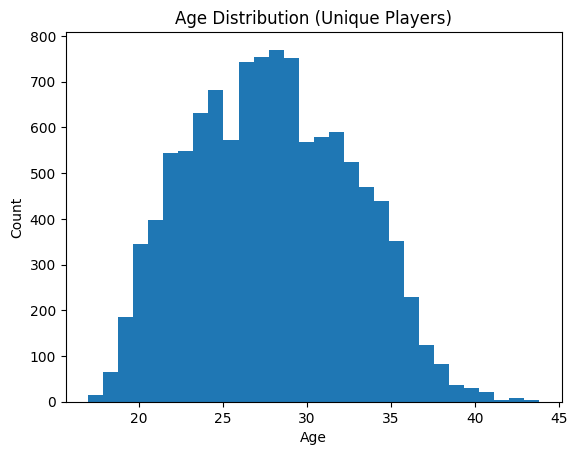

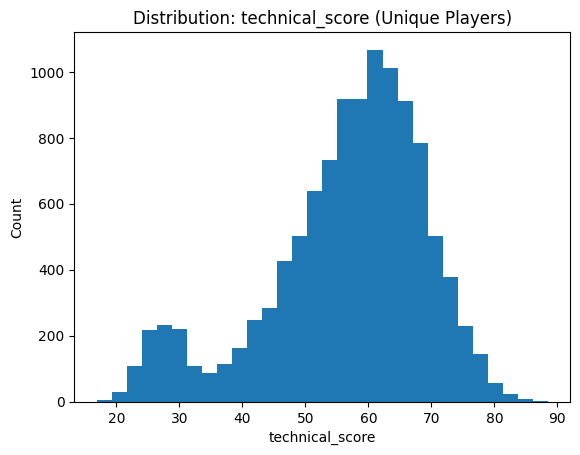

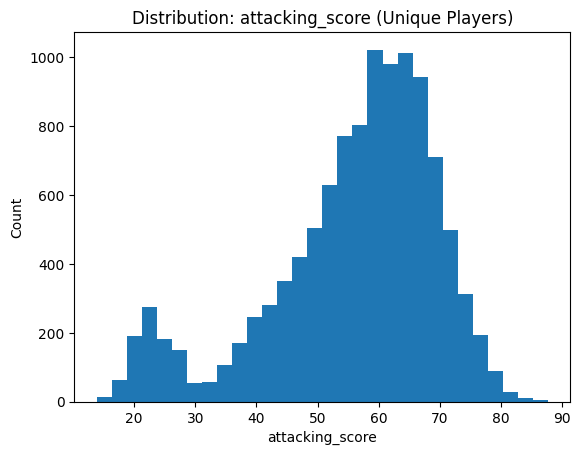

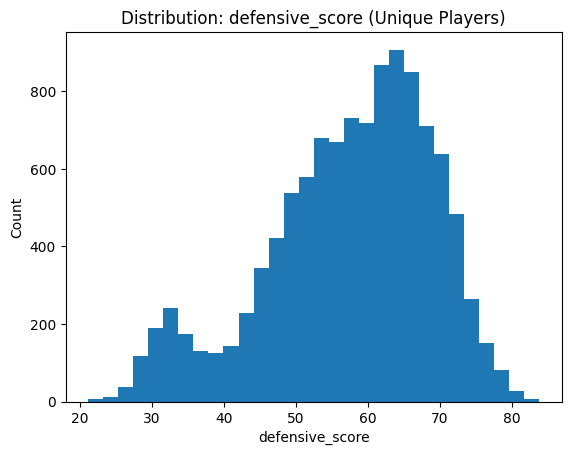

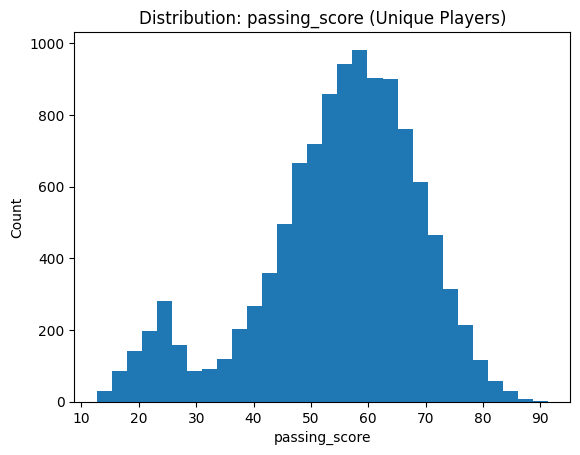

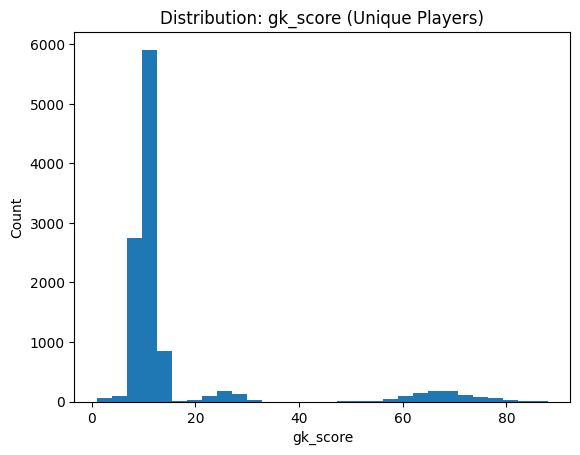

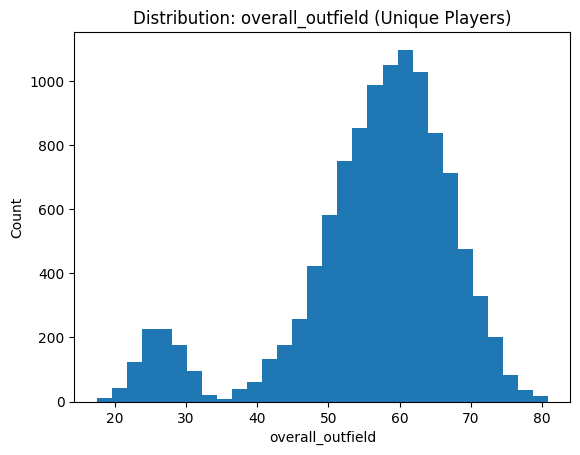

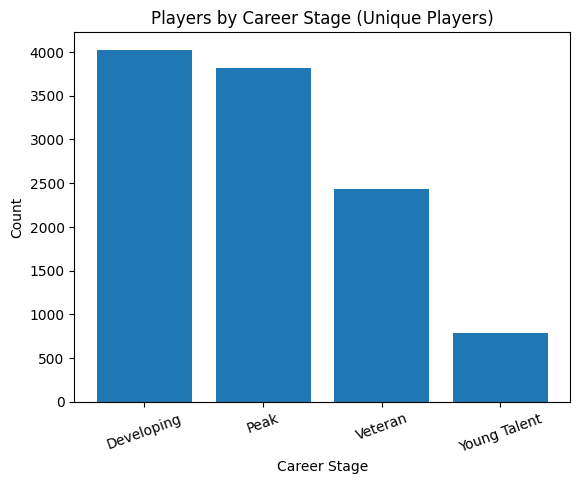

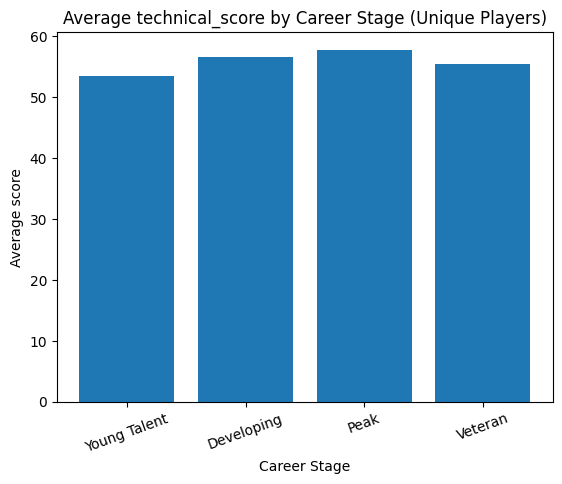

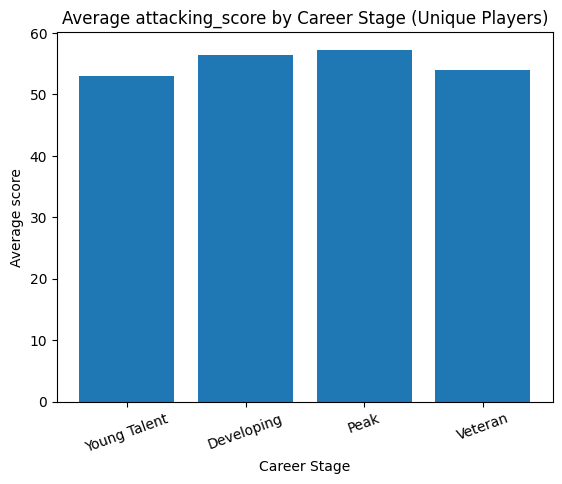

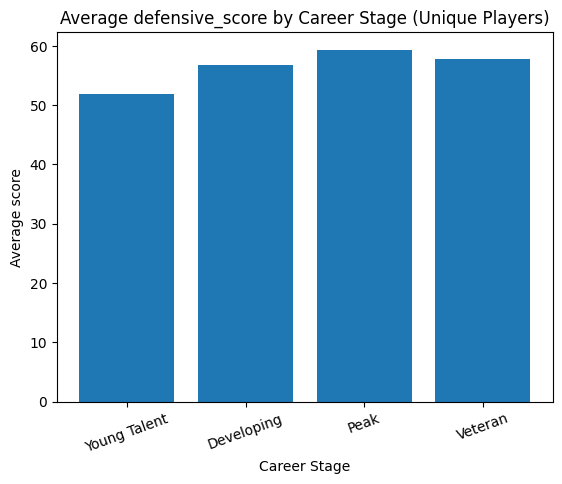

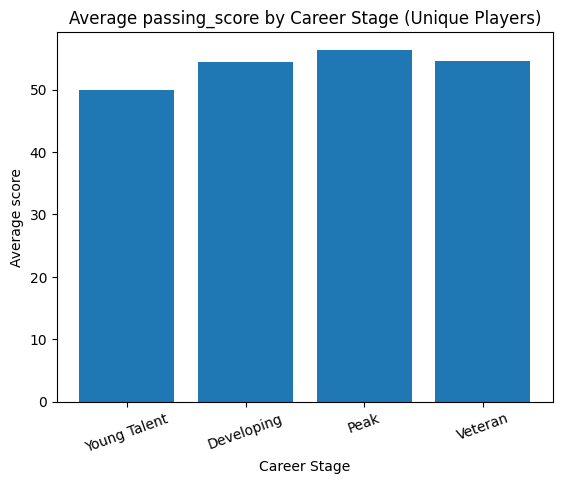

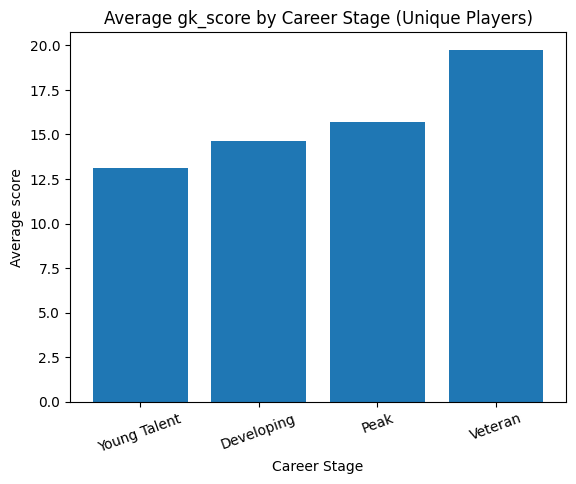

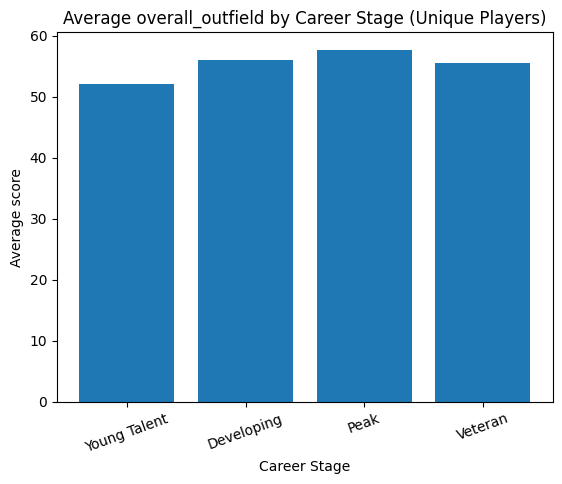

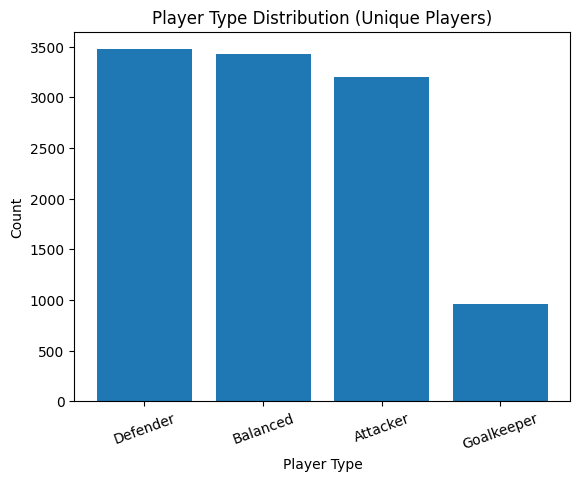

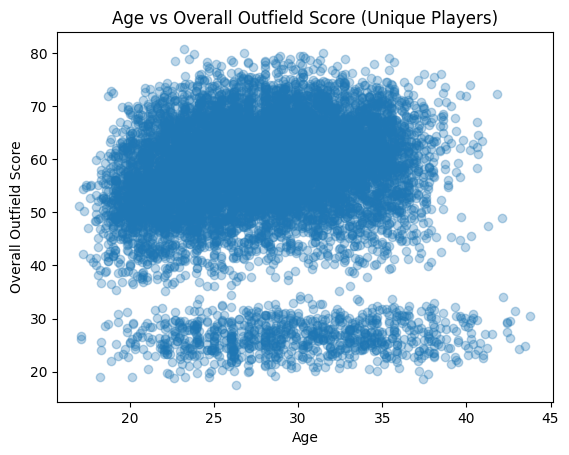

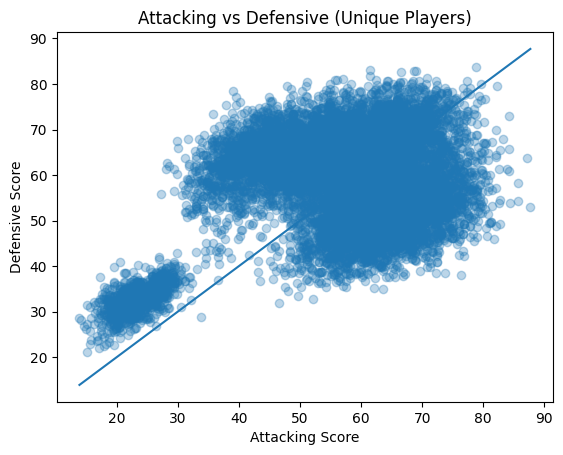


Top 10 UNIQUE Attackers by attacking_score (latest):
       player_name  age career_stage  attacking_score
      Lionel Messi 28.5         Peak             87.7
 Cristiano Ronaldo 30.7         Peak             87.2
        Marco Reus 27.0         Peak             85.6
      Arjen Robben 32.0      Veteran             85.6
       Eden Hazard 25.1   Developing             84.3
   James Rodriguez 24.6   Developing             84.2
       Luis Suarez 28.7         Peak             84.2
       Gareth Bale 26.8   Developing             84.2
Zlatan Ibrahimovic 34.0      Veteran             83.9
      Carlos Tevez 32.3      Veteran             83.3

Top 10 UNIQUE Defenders by defensive_score (latest):
              player_name  age career_stage  defensive_score
       Branislav Ivanovic 32.2      Veteran             83.0
             Sergio Ramos 30.0         Peak             82.9
             Thiago Silva 31.0         Peak             82.8
           Pablo Zabaleta 31.1         Peak           

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


df_player = pd.read_csv("Player.csv")
df_attr   = pd.read_csv("Player_Attributes_clean.csv")

df = df_attr.merge(
    df_player[['player_api_id', 'player_name', 'birthday']],
    on='player_api_id',
    how='left'
)

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['birthday'] = pd.to_datetime(df['birthday'], errors='coerce', dayfirst=True)

fallback_date = pd.to_datetime(df_attr['date'].astype(str), format='%Y%m%d', errors='coerce')
df.loc[df['date'].isna(), 'date'] = fallback_date[df['date'].isna()]

df['age'] = ((df['date'] - df['birthday']).dt.days / 365.25)

def career_stage(age):
    if pd.isna(age):
        return np.nan
    if age < 21:
        return "Young Talent"
    elif age < 27:
        return "Developing"
    elif age < 32:
        return "Peak"
    else:
        return "Veteran"

df['career_stage'] = df['age'].apply(career_stage)

technical_cols = [
    'ball_control','dribbling','agility','balance','reactions',
    'vision','short_passing','long_passing',
    'curve','crossing','free_kick_accuracy','penalties',
    'finishing','volleys','composure'
]
attacking_cols = [
    'finishing','shot_power','long_shots','volleys','penalties',
    'positioning','acceleration','sprint_speed',
    'dribbling','ball_control',
    'vision','short_passing','long_passing',
    'crossing','curve','free_kick_accuracy','composure'
]
defensive_cols = [
    'marking','interceptions',
    'standing_tackle','sliding_tackle',
    'strength','aggression',
    'jumping','heading_accuracy',
    'reactions','stamina','positioning'
]
passing_cols = [
    'short_passing','long_passing','vision',
    'crossing','curve','free_kick_accuracy'
]
gk_cols = [
    'gk_diving','gk_handling','gk_kicking','gk_reflexes','gk_positioning'
]

technical_cols = [c for c in technical_cols if c in df.columns]
attacking_cols = [c for c in attacking_cols if c in df.columns]
defensive_cols = [c for c in defensive_cols if c in df.columns]
passing_cols   = [c for c in passing_cols   if c in df.columns]
gk_cols        = [c for c in gk_cols        if c in df.columns]

all_skill_cols = sorted(set(technical_cols + attacking_cols + defensive_cols + passing_cols + gk_cols))
for c in all_skill_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df['technical_score'] = df[technical_cols].mean(axis=1) if technical_cols else np.nan
df['attacking_score'] = df[attacking_cols].mean(axis=1) if attacking_cols else np.nan
df['defensive_score'] = df[defensive_cols].mean(axis=1) if defensive_cols else np.nan
df['passing_score']   = df[passing_cols].mean(axis=1)   if passing_cols   else np.nan
df['gk_score']        = df[gk_cols].mean(axis=1)        if gk_cols        else 0.0

def player_type(row):
    if pd.notna(row['gk_score']) and row['gk_score'] >= 50:
        return "Goalkeeper"

    atk = row['attacking_score']
    dfn = row['defensive_score']
    if pd.isna(atk) or pd.isna(dfn):
        return np.nan

    if atk > dfn + 8:
        return "Attacker"
    if dfn > atk + 8:
        return "Defender"
    return "Balanced"

df['player_type'] = df.apply(player_type, axis=1)

df['overall_outfield'] = df[['technical_score','attacking_score','defensive_score','passing_score']].mean(axis=1)
df['atk_minus_def'] = df['attacking_score'] - df['defensive_score']

df['age'] = df['age'].round(1)
round_cols = ['technical_score','attacking_score','defensive_score','passing_score','gk_score','overall_outfield','atk_minus_def']
df[round_cols] = df[round_cols].round(1)

df.to_csv(
    "Player_Attributes_scored_TR.csv",
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

UNIQUE_STRATEGY = "latest"

if UNIQUE_STRATEGY == "latest":
    df_unique = (
        df.sort_values(['player_api_id', 'date'])
          .groupby('player_api_id', as_index=False)
          .tail(1)
          .copy()
    )
elif UNIQUE_STRATEGY == "peak":
    df_unique = (
        df.sort_values(['player_api_id', 'overall_outfield', 'date'])
          .groupby('player_api_id', as_index=False)
          .tail(1)
          .copy()
    )
else:
    raise ValueError("UNIQUE_STRATEGY must be 'latest' or 'peak'")

print(f"Unique players dataset built using strategy: {UNIQUE_STRATEGY}")
print(f"Unique rows: {len(df_unique)}")

num_cols = ['age','technical_score','attacking_score','defensive_score','passing_score','gk_score','overall_outfield','atk_minus_def']
for c in num_cols:
    df_unique[c] = pd.to_numeric(df_unique[c], errors='coerce')

df_plot = df_unique.dropna(subset=['age','technical_score','attacking_score','defensive_score','passing_score','gk_score','overall_outfield'])


plt.figure()
plt.hist(df_plot['age'], bins=30)
plt.title("Age Distribution (Unique Players)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

for col in ['technical_score','attacking_score','defensive_score','passing_score','gk_score','overall_outfield']:
    plt.figure()
    plt.hist(df_plot[col], bins=30)
    plt.title(f"Distribution: {col} (Unique Players)")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

stage_counts = df_plot['career_stage'].value_counts()
plt.figure()
plt.bar(stage_counts.index.astype(str), stage_counts.values)
plt.title("Players by Career Stage (Unique Players)")
plt.xlabel("Career Stage")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()


stage_means = df_plot.groupby('career_stage')[['technical_score','attacking_score','defensive_score','passing_score','gk_score','overall_outfield']].mean()
stage_means = stage_means.reindex(['Young Talent','Developing','Peak','Veteran'])
for col in stage_means.columns:
    plt.figure()
    plt.bar(stage_means.index.astype(str), stage_means[col].values)
    plt.title(f"Average {col} by Career Stage (Unique Players)")
    plt.xlabel("Career Stage")
    plt.ylabel("Average score")
    plt.xticks(rotation=20)
    plt.show()

type_counts = df_plot['player_type'].value_counts()
plt.figure()
plt.bar(type_counts.index.astype(str), type_counts.values)
plt.title("Player Type Distribution (Unique Players)")
plt.xlabel("Player Type")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()


plt.figure()
plt.scatter(df_plot['age'], df_plot['overall_outfield'], alpha=0.3)
plt.title("Age vs Overall Outfield Score (Unique Players)")
plt.xlabel("Age")
plt.ylabel("Overall Outfield Score")
plt.show()

plt.figure()
plt.scatter(df_plot['attacking_score'], df_plot['defensive_score'], alpha=0.3)
plt.title("Attacking vs Defensive (Unique Players)")
plt.xlabel("Attacking Score")
plt.ylabel("Defensive Score")
mn = min(df_plot['attacking_score'].min(), df_plot['defensive_score'].min())
mx = max(df_plot['attacking_score'].max(), df_plot['defensive_score'].max())
plt.plot([mn, mx], [mn, mx])
plt.show()

def show_top_unique(df_u, player_type, metric, n=10):
    sub = df_u[df_u['player_type'] == player_type].copy()
    top = sub.sort_values(metric, ascending=False).head(n)
    print(f"\nTop {n} UNIQUE {player_type}s by {metric} ({UNIQUE_STRATEGY}):")
    print(top[['player_name','age','career_stage',metric]].to_string(index=False))

show_top_unique(df_plot, "Attacker", "attacking_score", n=10)
show_top_unique(df_plot, "Defender", "defensive_score", n=10)
show_top_unique(df_plot, "Balanced", "overall_outfield", n=10)
show_top_unique(df_plot, "Goalkeeper", "gk_score", n=10)

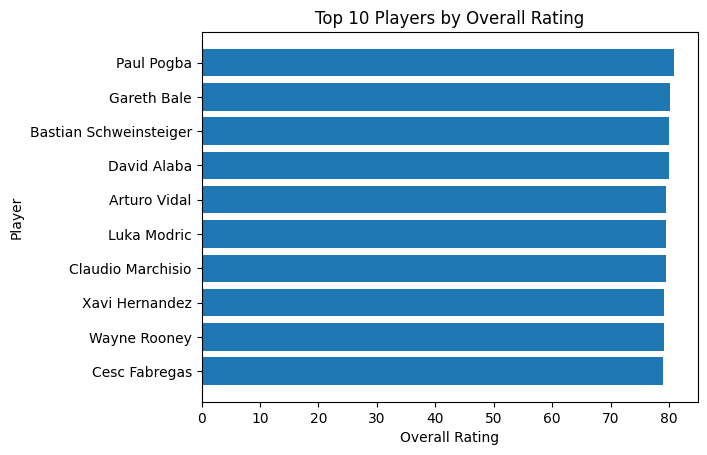

In [ ]:
top_overall = df_plot.sort_values("overall_outfield", ascending=False).head(10)

plt.figure()

plt.barh(
    top_overall["player_name"],
    top_overall["overall_outfield"]
)

plt.title("Top 10 Players by Overall Rating")
plt.xlabel("Overall Rating")
plt.ylabel("Player")

plt.gca().invert_yaxis()

plt.show()


Average Overall Score by Preferred Foot:

preferred_foot
left     58.374572
right    55.501552
Name: overall_outfield, dtype: float64

Median Overall Score by Preferred Foot:

preferred_foot
left     59.9
right    57.7
Name: overall_outfield, dtype: float64

Player Count by Preferred Foot:

preferred_foot
right    8374
left     2686
Name: count, dtype: int64


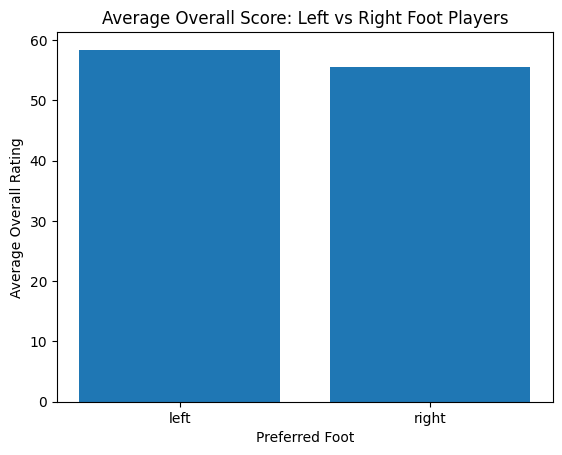

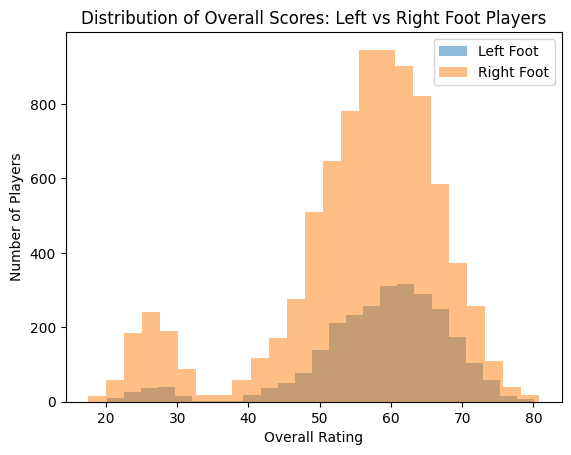

In [ ]:
import matplotlib.pyplot as plt


foot_avg = df_plot.groupby("preferred_foot")["overall_outfield"].mean()

print("\nAverage Overall Score by Preferred Foot:\n")
print(foot_avg)

foot_median = df_plot.groupby("preferred_foot")["overall_outfield"].median()

print("\nMedian Overall Score by Preferred Foot:\n")
print(foot_median)


foot_counts = df_plot["preferred_foot"].value_counts()

print("\nPlayer Count by Preferred Foot:\n")
print(foot_counts)

plt.figure()

plt.bar(
    foot_avg.index.astype(str),
    foot_avg.values
)

plt.title("Average Overall Score: Left vs Right Foot Players")
plt.xlabel("Preferred Foot")
plt.ylabel("Average Overall Rating")

plt.show()


left_scores = df_plot[df_plot["preferred_foot"] == "left"]["overall_outfield"]
right_scores = df_plot[df_plot["preferred_foot"] == "right"]["overall_outfield"]

plt.figure()

plt.hist(left_scores, bins=25, alpha=0.5)
plt.hist(right_scores, bins=25, alpha=0.5)

plt.title("Distribution of Overall Scores: Left vs Right Foot Players")
plt.xlabel("Overall Rating")
plt.ylabel("Number of Players")

plt.legend(["Left Foot", "Right Foot"])

plt.show()